# μP Learning Rate Transfer for MOE Models

This notebook generates plots showing learning rate vs training loss curves for all combinations of model width and expert count in the MOE (Mixture of Experts) architecture with μP (Maximal Update Parametrization).

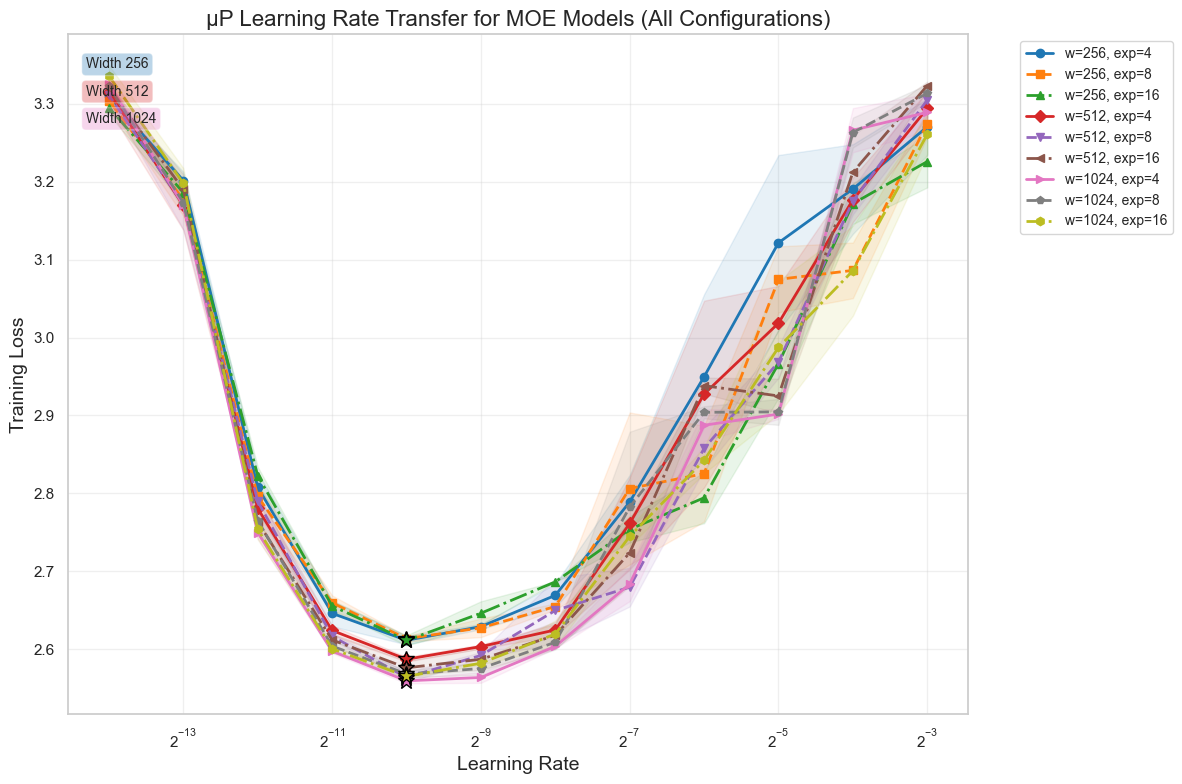


Optimal Learning Rates:

Experts = 4:
  Width 256: LR = 0.000977, Loss = 2.6113
  Width 512: LR = 0.000977, Loss = 2.5869
  Width 1024: LR = 0.000977, Loss = 2.5592

Experts = 8:
  Width 256: LR = 0.000977, Loss = 2.6134
  Width 512: LR = 0.000977, Loss = 2.5635
  Width 1024: LR = 0.000977, Loss = 2.5681

Experts = 16:
  Width 256: LR = 0.000977, Loss = 2.6111
  Width 512: LR = 0.000977, Loss = 2.5759
  Width 1024: LR = 0.000977, Loss = 2.5649


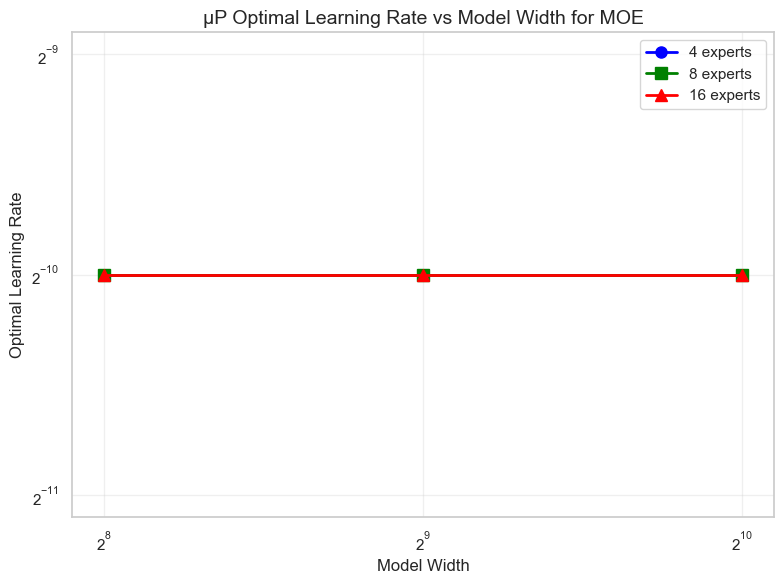

In [3]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import seaborn as sns
sns.set(style='whitegrid')

# Parameters from run.ps1
seeds = [1, 2, 3]
widths = [
    256,
    512,
    1024,
    # 2048,  # Excluding as requested since some runs are incomplete
]
num_exps = [4, 8, 16]  # Number of experts
num_act = 2  # Number of active experts (top-k)

lrs = [
    0.125,
    0.0625,
    0.03125,
    0.015625,
    0.0078125,
    0.00390625,
    0.001953125,
    0.0009765625,
    0.00048828125,
    0.000244140625,
    0.0001220703125,
    0.00006103515625,
]

# Create one large plot with all configurations
plt.figure(figsize=(12, 8))

# Color and marker helpers for different combinations
# Using a colormap for better visual distinction
cmap = plt.cm.tab10
colors = [cmap(i) for i in range(10)]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h']
linestyles = ['-', '--', '-.']

# Track all configurations for legend
all_configs = []

for width_idx, width in enumerate(widths):
    for exp_idx, n_exp in enumerate(num_exps):
        mean_losses = []
        sem_losses = []
        lrs_to_plot = []
        
        for lr in lrs:
            losses = []
            for seed in seeds:
                # Construct the job name following the format from run.ps1
                job_name = f'width{width}_depth2_experts{n_exp}_active{num_act}_seed{seed}_lr{lr}'
                csv_path = os.path.join('mup_moe', 'out', job_name, 'log.csv')
                
                if os.path.exists(csv_path):
                    try:
                        ckpt_df = pd.read_csv(csv_path)
                        if len(ckpt_df) > 50:  # Only include runs with sufficient iterations
                            # Use mean of last 20 iterations to get stable loss
                            losses.append(ckpt_df['train/loss'].tail(20).mean())
                    except:
                        pass  # Skip corrupted files
            
            if len(losses) >= 2:  # Only include if we have at least 2 seeds
                mean_losses.append(np.mean(losses))
                sem_losses.append(np.std(losses, ddof=1) / np.sqrt(len(losses)))
                lrs_to_plot.append(lr)
        
        if len(mean_losses) > 0:
            mean_losses = np.array(mean_losses)
            sem_losses = np.array(sem_losses)
            
            # Choose color and marker based on configuration
            config_idx = width_idx * len(num_exps) + exp_idx
            color = colors[config_idx % len(colors)]
            marker = markers[config_idx % len(markers)]
            linestyle = linestyles[exp_idx % len(linestyles)]
            
            # Plot with error bars
            line, = plt.plot(lrs_to_plot, mean_losses, 
                   label=f'w={width}, exp={n_exp}', 
                   marker=marker, 
                   color=color,
                   linestyle=linestyle,
                   linewidth=2,
                   markersize=6)
            all_configs.append(line)
            
            # Add error bars as shaded area
            plt.fill_between(lrs_to_plot, 
                           mean_losses-sem_losses, 
                           mean_losses+sem_losses, 
                           color=color, 
                           alpha=0.1)
            
            # Mark optimal learning rate with a star
            optimum_idx = np.argmin(mean_losses)
            plt.plot(lrs_to_plot[optimum_idx], mean_losses[optimum_idx], 
                   color=color, 
                   marker='*', markersize=12, 
                   markeredgecolor='black', markeredgewidth=1,
                   zorder=10)  # Ensure stars appear on top

plt.xscale('log', base=2)
plt.xlabel('Learning Rate', fontsize=14)
plt.ylabel('Training Loss', fontsize=14)
plt.title('μP Learning Rate Transfer for MOE Models (All Configurations)', fontsize=16)
plt.grid(True, alpha=0.3)

# Create a more compact legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, ncol=1)

# Add annotations to distinguish width groups
ax = plt.gca()
y_min, y_max = ax.get_ylim()
text_y = y_max * 0.98

# Add text annotations for width groups
for width_idx, width in enumerate(widths):
    color_for_width = colors[(width_idx * len(num_exps)) % len(colors)]
    plt.text(0.02, 0.95 - width_idx * 0.04, f'Width {width}', 
             transform=ax.transAxes, fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor=color_for_width, alpha=0.3))

plt.tight_layout()
plt.savefig('mup_moe_lr_transfer_merged.png', dpi=300, bbox_inches='tight')
plt.show()

# Print optimal learning rates for each configuration
print("\nOptimal Learning Rates:")
print("=" * 50)
for n_exp in num_exps:
    print(f"\nExperts = {n_exp}:")
    for width in widths:
        mean_losses = []
        lrs_list = []
        for lr in lrs:
            losses = []
            for seed in seeds:
                job_name = f'width{width}_depth2_experts{n_exp}_active{num_act}_seed{seed}_lr{lr}'
                csv_path = os.path.join('mup_moe', 'out', job_name, 'log.csv')
                if os.path.exists(csv_path):
                    try:
                        ckpt_df = pd.read_csv(csv_path)
                        if len(ckpt_df) > 50:
                            losses.append(ckpt_df['train/loss'].tail(20).mean())
                    except:
                        pass
            if len(losses) >= 2:
                mean_losses.append(np.mean(losses))
                lrs_list.append(lr)
        
        if len(mean_losses) > 0:
            optimum_idx = np.argmin(mean_losses)
            print(f"  Width {width}: LR = {lrs_list[optimum_idx]:.6f}, Loss = {mean_losses[optimum_idx]:.4f}")

# Create a second plot showing optimal LR vs width for different expert counts
plt.figure(figsize=(8, 6))

markers = ['o', 's', '^']
colors_exp = ['blue', 'green', 'red']

for exp_idx, n_exp in enumerate(num_exps):
    optimal_lrs = []
    widths_with_data = []
    
    for width in widths:
        mean_losses = []
        lrs_list = []
        
        for lr in lrs:
            losses = []
            for seed in seeds:
                job_name = f'width{width}_depth2_experts{n_exp}_active{num_act}_seed{seed}_lr{lr}'
                csv_path = os.path.join('mup_moe', 'out', job_name, 'log.csv')
                if os.path.exists(csv_path):
                    try:
                        ckpt_df = pd.read_csv(csv_path)
                        if len(ckpt_df) > 50:
                            losses.append(ckpt_df['train/loss'].tail(20).mean())
                    except:
                        pass
            
            if len(losses) >= 2:
                mean_losses.append(np.mean(losses))
                lrs_list.append(lr)
        
        if len(mean_losses) > 0:
            optimum_idx = np.argmin(mean_losses)
            optimal_lrs.append(lrs_list[optimum_idx])
            widths_with_data.append(width)
    
    if len(optimal_lrs) > 0:
        plt.plot(widths_with_data, optimal_lrs, 
                marker=markers[exp_idx], 
                color=colors_exp[exp_idx],
                label=f'{n_exp} experts',
                linewidth=2,
                markersize=8)

plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('Model Width', fontsize=12)
plt.ylabel('Optimal Learning Rate', fontsize=12)
plt.title('μP Optimal Learning Rate vs Model Width for MOE', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mup_moe_optimal_lr_vs_width.png', dpi=300, bbox_inches='tight')
plt.show()

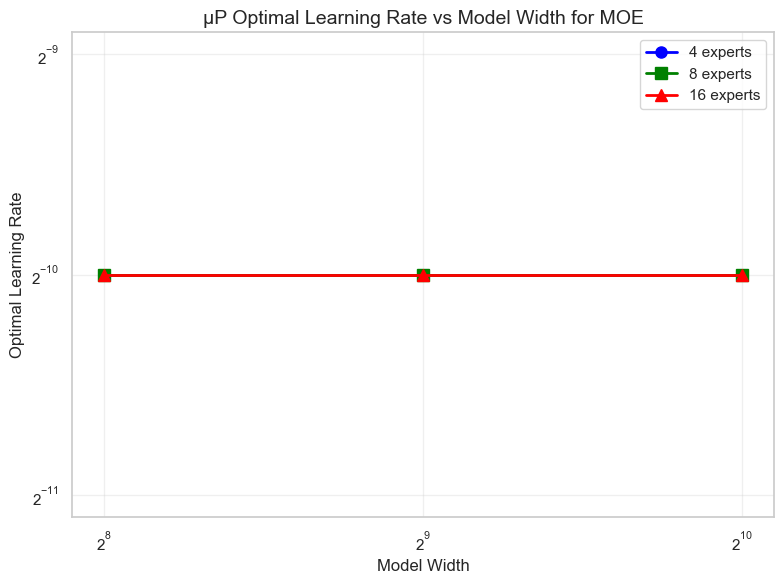

In [2]:
# Create a combined plot showing optimal LR vs width for different expert counts
plt.figure(figsize=(8, 6))

markers = ['o', 's', '^']
colors = ['blue', 'green', 'red']

for exp_idx, n_exp in enumerate(num_exps):
    optimal_lrs = []
    widths_with_data = []
    
    for width in widths:
        mean_losses = []
        lrs_list = []
        
        for lr in lrs:
            losses = []
            for seed in seeds:
                job_name = f'width{width}_depth2_experts{n_exp}_active{num_act}_seed{seed}_lr{lr}'
                csv_path = os.path.join('mup_moe', 'out', job_name, 'log.csv')
                if os.path.exists(csv_path):
                    try:
                        ckpt_df = pd.read_csv(csv_path)
                        if len(ckpt_df) > 50:
                            losses.append(ckpt_df['train/loss'].tail(20).mean())
                    except:
                        pass
            
            if len(losses) >= 2:
                mean_losses.append(np.mean(losses))
                lrs_list.append(lr)
        
        if len(mean_losses) > 0:
            optimum_idx = np.argmin(mean_losses)
            optimal_lrs.append(lrs_list[optimum_idx])
            widths_with_data.append(width)
    
    if len(optimal_lrs) > 0:
        plt.plot(widths_with_data, optimal_lrs, 
                marker=markers[exp_idx], 
                color=colors[exp_idx],
                label=f'{n_exp} experts',
                linewidth=2,
                markersize=8)

plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('Model Width', fontsize=12)
plt.ylabel('Optimal Learning Rate', fontsize=12)
plt.title('μP Optimal Learning Rate vs Model Width for MOE', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mup_moe_optimal_lr_vs_width.png', dpi=300, bbox_inches='tight')
plt.show()
